# De cero a producción: el ciclo de vida completo de lima-rent-ml

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josefrodrim/lima-rent-ml/blob/main/notebooks/clase_magistral.ipynb)

Este notebook es distinto al del taller: acá no hay `# TODO` que resolver,
todo corre solo. La idea es que lo vayas ejecutando celda por celda mientras
alguien narra qué se hizo en cada paso y por qué — de una idea ("¿cuánto vale
mi alquiler?") a una aplicación real, viva en internet, ahora mismo, en
[https://lima-rent-ml.vercel.app](https://lima-rent-ml.vercel.app).

Recorremos 5 partes:

1. **Los datos** — de la nada a un dataset limpio.
2. **El modelo tonto** — el rival que hay que vencer.
3. **El modelo de verdad** — LightGBM.
4. **Entender al modelo** — por qué predice lo que predice.
5. **A producción** — servirlo por una API y desplegarlo de verdad, con los
   problemas reales que aparecieron en el camino (y no aparecen en ningún
   tutorial de 10 minutos).


In [ ]:
!git clone -q https://github.com/josefrodrim/lima-rent-ml.git
%cd lima-rent-ml
%pip install -q -e ".[notebook,train]"

# Un kernel ya corriendo no recoge un editable install nuevo sin reiniciar
# (Python solo procesa los .pth de pip en el arranque del intérprete), así
# que agregamos src/ al path a mano en vez de reiniciar el runtime.
import sys

sys.path.insert(0, "src")


In [2]:
import numpy as np
import pandas as pd
import requests
from IPython.display import HTML, display

from lima_rent.config import CLEAN_DATA_PATH, COLOR_MAGENTA, SEED
from lima_rent.explain import predict_contributions, shap_explainer, top_factors
from lima_rent.features import build_features
from lima_rent.models.baseline import fit_district_medians, predict_baseline
from lima_rent.models.train import train as run_training
from lima_rent.viz import build_price_heatmap, plot_distance_vs_price, plot_price_per_m2_by_district

pd.set_option("display.max_columns", 20)


## Parte 0 — El problema, en una frase

Queremos predecir el precio de alquiler (S/) de un departamento en Lima
Metropolitana a partir de sus características (distrito, área, dormitorios,
etc.) y su ubicación exacta. Es un problema de **regresión**: la respuesta es
un número, no una categoría.

Por qué este caso funciona para explicar Machine Learning:
- Se entiende en 10 segundos, sin conocer nada de ciencia de datos.
- El error se dice en soles ("el modelo se equivoca en promedio S/ 180"), no
  hay que explicar ninguna métrica rara.
- Es geoespacial — un mapa de calor vende la idea solo, sin necesitar texto.


## Parte 1 — Los datos: de la nada a un dataset

**No usamos datos reales de ningún portal.** Los generamos nosotros con un
script (`generate.py`), de forma determinista — dos personas que lo corran
el mismo día obtienen exactamente el mismo dataset. Esto evita depender de
scrapers que se pueden caer justo el día del taller, y evita problemas de
licencia de datos que no son nuestros.

Eso sí: la ecuación que genera los precios está diseñada para que las
relaciones que le vamos a pedir al modelo que aprenda — más cerca del
transporte público es más caro, más área es más caro, etc. — existan de
verdad en los datos, con ruido realista encima.


In [3]:
!python -m lima_rent.data.generate
!python -m lima_rent.data.clean

df = pd.read_csv(CLEAN_DATA_PATH)
df["price_per_m2"] = df["price_pen"] / df["area_m2"]
print(f"{len(df):,} avisos limpios, {df['district'].nunique()} distritos")
df.head()


Generadas 8015 filas -> /private/tmp/masterclass_e2e/lima-rent-ml/data/raw/listings_raw.csv


Raw: 8015 filas -> Clean: 7800 filas -> /private/tmp/masterclass_e2e/lima-rent-ml/data/processed/listings_clean.csv


7,800 avisos limpios, 18 distritos


,listing_id,district,latitude,longitude,area_m2,bedrooms,bathrooms,floor,has_parking,has_elevator,is_furnished,building_age_years,dist_to_station_km,posted_date,price_pen,price_per_m2
0,LIM-00001,San Miguel,-12.092527,-77.093513,69.5,1,2,4,False,True,False,38,7.665,2026-07-10,2500.0,35.971223
1,LIM-00002,Magdalena del Mar,-12.090796,-77.096885,67.2,3,1,10,True,True,False,17,7.859,2026-03-19,3400.0,50.595238
2,LIM-00003,Chorrillos,-12.173328,-77.028837,81.9,2,2,5,False,False,False,8,1.337,2026-03-01,3000.0,36.630037
3,LIM-00004,Pueblo Libre,-12.069074,-77.074578,115.4,4,3,3,True,False,False,8,4.567,2026-06-21,5700.0,49.393414
4,LIM-00005,Miraflores,-12.115441,-77.033198,87.2,2,2,12,True,False,True,14,2.124,2026-07-11,8400.0,96.330275


In [4]:
df.describe()


,latitude,longitude,area_m2,bedrooms,bathrooms,floor,building_age_years,dist_to_station_km,price_pen,price_per_m2
count,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000
mean,-12.095069,-77.030247,87.540500,2.490256,1.789359,7.537949,13.688846,3.228331,5203.987179,58.973148
std,0.047284,0.042088,31.261932,1.005515,0.780822,4.077823,9.441595,2.490899,2848.645895,21.513291
min,-12.210913,-77.152615,25.000000,1.000000,1.000000,1.000000,0.000000,0.008000,750.000000,18.742443
25%,-12.124571,-77.057736,65.200000,2.000000,1.000000,4.000000,7.000000,1.320500,3150.000000,43.621548
50%,-12.100186,-77.030419,82.700000,2.000000,2.000000,7.000000,12.000000,2.509000,4550.000000,55.032186
75%,-12.076441,-77.007127,103.900000,3.000000,2.000000,10.000000,19.000000,4.473500,6550.000000,73.434111
max,-11.917511,-76.889348,300.000000,5.000000,4.000000,20.000000,45.000000,13.094000,27850.000000,150.048876


**El mapa de calor**: cada punto es un aviso, coloreado por precio/m². Los puntos magenta son estaciones de transporte público.


In [5]:
build_price_heatmap(df, value_col="price_per_m2")


**Precio por m² según distrito** — la variación entre distritos es enorme, y es la primera señal que el modelo va a usar.


In [6]:
plot_price_per_m2_by_district(df)


**Precio vs. distancia a una estación** — mientras más lejos, más barato, en promedio. Esta es la relación que más le cuesta "ver" al modelo tonto.


In [7]:
plot_distance_vs_price(df)


## Parte 2 — El modelo tonto (baseline)

Antes de entrenar nada "de verdad", construimos el rival más simple posible:
predecir cada aviso con la **mediana de precio/m² de su distrito**,
multiplicada por su área. Nada de dormitorios, cochera, ascensor, ni
distancia a una estación — el baseline ignora todo eso.

¿Para qué sirve un modelo tan simple? Sin él, un error de "S/ 180" no
significa nada. Con él, sabemos exactamente cuánto mejor es el modelo de
verdad — y si algún día el modelo de verdad no le gana por mucho al
baseline, es una señal de que algo anda mal.


In [8]:
medians = fit_district_medians(df)
baseline_pred = predict_baseline(df, medians)
baseline_mae = (df["price_pen"] - baseline_pred).abs().mean()

display(HTML(f"<h2 style='color:{COLOR_MAGENTA}'>MAE del modelo tonto: S/ {baseline_mae:,.0f}</h2>"))


## Parte 3 — El modelo de verdad: LightGBM

LightGBM es un modelo de **gradient boosting**: entrena cientos de árboles
de decisión pequeños, uno detrás de otro, donde cada árbol nuevo se enfoca en
corregir los errores que dejaron los anteriores. Es rápido, funciona muy bien
con columnas categóricas (como "distrito") sin trucos raros, y es el
estándar de la industria para este tipo de problema tabular.

La celda de abajo entrena exactamente el mismo pipeline que usa la API en
producción (`lima_rent.models.train.train`) — el número que vas a ver acá es
el mismo que ve un usuario real de la app ahora mismo.


In [9]:
artifact = run_training()

print()
print(f"Modelo tonto (baseline):  S/ {artifact.metrics['baseline_mae_pen']:,.0f}")
print(f"LightGBM:                 S/ {artifact.metrics['lgbm_mae_pen']:,.0f}")
print(f"Tiempo de entrenamiento:  {artifact.metrics['train_seconds']:.2f}s")


2026/08/11 07:59:28 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/11 07:59:28 INFO mlflow.store.db.utils: Updating database tables


Baseline MAE (test): S/ 591.7
LightGBM MAE (test): S/ 188.5
Tiempo de entrenamiento: 4.10s

Criterios de aceptación OK.

Modelo tonto (baseline):  S/ 592
LightGBM:                 S/ 189
Tiempo de entrenamiento:  4.10s


In [10]:
import plotly.graph_objects as go

from lima_rent.config import COLOR_BLUE, COLOR_NAVY

fig = go.Figure(
    go.Bar(
        x=["Modelo tonto", "LightGBM"],
        y=[artifact.metrics["baseline_mae_pen"], artifact.metrics["lgbm_mae_pen"]],
        marker_color=[COLOR_NAVY, COLOR_BLUE],
        text=[f"S/ {v:,.0f}" for v in [artifact.metrics["baseline_mae_pen"], artifact.metrics["lgbm_mae_pen"]]],
        textposition="outside",
    )
)
fig.update_layout(title="Error promedio (MAE): menos es mejor", yaxis_title="S/", template="plotly_white")
fig.show()


## Parte 4 — Entender al modelo, no solo confiar en él

Un modelo que solo escupe un número no genera confianza. Necesitamos poder
decirle a alguien: "tu depa vale más por esto, y vale menos por esto otro" —
en el mismo lenguaje que usaría una persona, no en jerga de estadística.

Usamos **SHAP** (SHapley Additive exPlanations): para cada aviso, reparte el
precio predicho en la contribución exacta de cada característica, de forma
que todas las contribuciones sumadas dan exactamente la predicción. Abajo,
el *waterfall* de un aviso real del dataset.


Aviso: San Miguel, 69.5 m²
Precio real:     S/ 2,500
Precio predicho: S/ 2,596


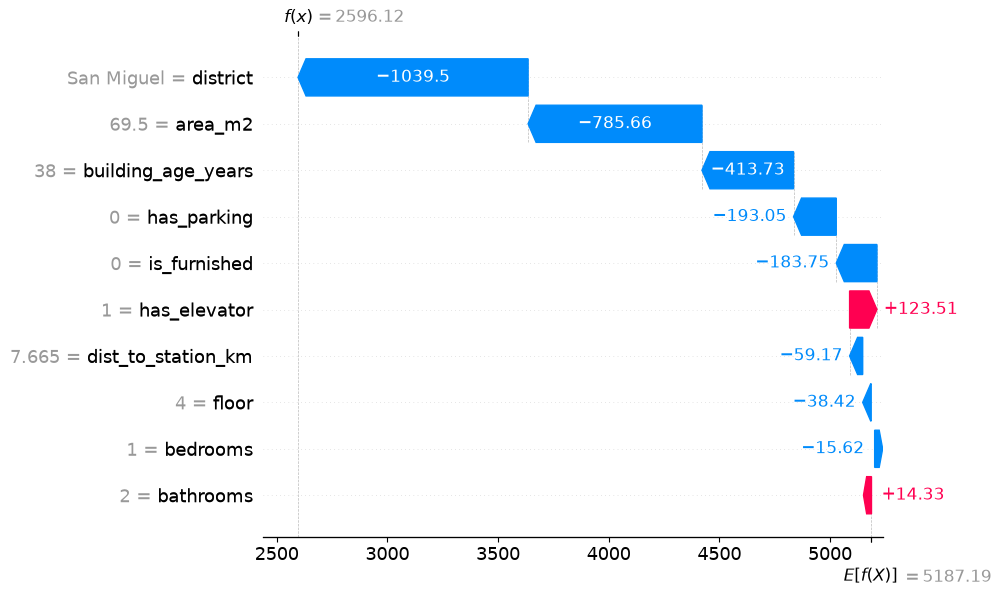

In [11]:
listing_idx = 0
listing_row = build_features(df.iloc[[listing_idx]])
predicted_price = artifact.model.booster_.predict(listing_row)[0]

print(f"Aviso: {df.iloc[listing_idx]['district']}, {df.iloc[listing_idx]['area_m2']} m²")
print(f"Precio real:     S/ {df.iloc[listing_idx]['price_pen']:,.0f}")
print(f"Precio predicho: S/ {predicted_price:,.0f}")

explainer = shap_explainer(artifact.model)
shap_values = explainer(listing_row)
shap_values.base_values = np.asarray(shap_values.base_values).reshape(-1)

import shap

shap.plots.waterfall(shap_values[0])


Y la traducción a lenguaje humano — esto es literalmente lo que la app le muestra a un usuario real:


In [12]:
contributions = predict_contributions(artifact.model, listing_row)

for f in top_factors(contributions, top_n=3):
    verbo = "suma" if f["contribution_pen"] >= 0 else "resta"
    print(f"- {f['label']} {verbo} ~S/ {abs(f['contribution_pen']):.0f}")


- Distrito resta ~S/ 1040
- Área resta ~S/ 786
- Antigüedad resta ~S/ 414


## Parte 5 — Sirviendo el modelo: la API

Tener un modelo entrenado en un notebook no le sirve a nadie más que a
nosotros. Para que una aplicación web lo pueda usar, lo ponemos detrás de
una **API**: un mesero que recibe un pedido (las características de un
departamento, en JSON), se lo lleva a la cocina (el modelo), y trae de
vuelta la respuesta (el precio estimado).

Nuestra API (`api/main.py`, FastAPI) tiene 4 rutas:

| Ruta | Qué hace |
|---|---|
| `GET /health` | ¿Está viva la API? |
| `POST /predict` | Precio + explicación (SHAP) |
| `POST /predict/baseline` | Precio del modelo tonto |
| `GET /districts` | Mediana de precio/m² por distrito |

Abajo la probamos **sin levantar ningún servidor** — `TestClient` simula
requests HTTP directamente contra el código de la API, en el mismo proceso
del notebook.


In [13]:
from fastapi.testclient import TestClient

from api.main import app

client = TestClient(app)

response = client.post(
    "/predict",
    json={
        "district": "Miraflores",
        "area_m2": 65,
        "bedrooms": 2,
        "bathrooms": 1,
        "floor": 8,
        "has_parking": True,
        "has_elevator": True,
        "is_furnished": False,
        "building_age_years": 10,
        "latitude": -12.1211,
        "longitude": -77.0294,
    },
)
print(f"HTTP {response.status_code}")
response.json()


HTTP 200


/private/tmp/masterclass_e2e/.venv/lib/python3.14/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


{'predicted_price_pen': 5526.1,
 'model_version': '20260811-125933',
 'confidence_interval': [5337.6, 5714.7],
 'base_value_pen': 5187.2,
 'dist_to_station_km': 1.668,
 'top_factors': [{'feature': 'district',
   'label': 'Distrito',
   'contribution_pen': 1845.1},
  {'feature': 'area_m2', 'label': 'Área', 'contribution_pen': -1606.1},
  {'feature': 'has_parking', 'label': 'Cochera', 'contribution_pen': 373.0}],
 'all_factors': [{'feature': 'district',
   'label': 'Distrito',
   'contribution_pen': 1845.1},
  {'feature': 'area_m2', 'label': 'Área', 'contribution_pen': -1606.1},
  {'feature': 'has_parking', 'label': 'Cochera', 'contribution_pen': 373.0},
  {'feature': 'bathrooms', 'label': 'Baños', 'contribution_pen': -289.3},
  {'feature': 'is_furnished', 'label': 'Amoblado', 'contribution_pen': -261.3},
  {'feature': 'has_elevator', 'label': 'Ascensor', 'contribution_pen': 166.9},
  {'feature': 'building_age_years',
   'label': 'Antigüedad',
   'contribution_pen': 107.0},
  {'feature':

## Parte 6 — A producción de verdad

"Producción" significa una sola cosa: **cualquiera con un link puede usarlo,
no solo vos en tu laptop.** Nuestra arquitectura tiene dos piezas que
conviven en el mismo dominio, desplegadas en Vercel:

- **Next.js** — la cara bonita: el formulario, el mapa, los gráficos.
- **La función Python** (`api/main.py`) — el cerebro: cada vez que alguien
  mueve el pin en el mapa, esta función corre el modelo y devuelve un precio
  nuevo, en vivo.

### Los 4 problemas reales que aparecieron al desplegar

Ningún tutorial de 10 minutos te cuenta esto — pero es el 90% del trabajo
real de poner un modelo en producción. Los dejamos acá tal cual pasaron:

1. **Le faltaba una pieza al sistema operativo.** LightGBM necesita una
   librería del sistema (`libgomp`, para hacer cuentas en paralelo) que ni
   Docker ni el servidor de Vercel traen instalada por defecto. Solución: la
   empaquetamos nosotros mismos junto con el código y la cargamos a mano
   antes de importar el modelo.
2. **El modelo pedía una librería que decidimos no llevar a producción.**
   Para no inflar el tamaño del servidor, no instalamos scikit-learn ahí —
   pero una parte del código de LightGBM la necesitaba sin que lo
   supiéramos. Solución: usamos una función más interna del modelo que no
   depende de ella.
3. **El servidor no entendía que había DOS programas en un mismo
   proyecto** (la página web y el modelo). Al principio, construía solo uno
   y ni la página cargaba. Solución: le dijimos explícitamente qué construir
   con cada herramienta.
4. **Nuestro propio código no se encontraba a sí mismo.** Cuando la función
   se "despertaba" en el servidor, no sabía dónde buscar el resto de
   nuestros archivos. Solución: le dimos la dirección exacta.

Cada uno se encontró probando de verdad contra el servidor real — no
adivinando. Esa es, quizás, la lección más importante de esta parte: **un
modelo que funciona en tu laptop no es lo mismo que un modelo en
producción**, y la única forma de confiar en que funciona es probarlo donde
de verdad va a vivir.

### La prueba: le preguntamos a la app real, ahora mismo


In [14]:
resp = requests.get("https://lima-rent-ml.vercel.app/health", timeout=10)
print(f"HTTP {resp.status_code}")
resp.json()


HTTP 200


{'status': 'ok', 'model_version': '20260811-124246'}

---

## El viaje completo, resumido

1. Generamos datos sintéticos deterministas, con relaciones realistas.
2. Construimos un modelo tonto para tener con qué comparar.
3. Entrenamos LightGBM: bajó el error de ~S/ 592 a ~S/ 188 (los números exactos de tu corrida están un poco más arriba).
4. Le pedimos al modelo que explique sus propias predicciones con SHAP.
5. Lo pusimos detrás de una API.
6. Lo desplegamos de verdad — y arreglamos los problemas reales que
   aparecieron en el camino.

**Fuera de alcance a propósito** (para explorar por tu cuenta): validación
espacial vs. aleatoria, monitoreo de drift, tuning de hiperparámetros en
serio, tests exhaustivos, feature store.

Repo completo: [https://github.com/josefrodrim/lima-rent-ml](https://github.com/josefrodrim/lima-rent-ml) · App en vivo: [https://lima-rent-ml.vercel.app](https://lima-rent-ml.vercel.app)
